Compiling model...
'compile' took 0.000398 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [6.62e-02, 1.28e+00, 0.00e+00, 1.00e+00]    [5.86e-02, 1.32e+00, 0.00e+00, 1.00e+00]    [1.59e+00]    
1000      [9.14e-03, 8.50e-03, 8.47e-09, 3.89e-04]    [1.04e-02, 8.48e-03, 8.47e-09, 3.89e-04]    [8.14e-01]    
2000      [5.43e-03, 4.39e-03, 1.35e-06, 1.25e-04]    [5.68e-03, 4.65e-03, 1.35e-06, 1.25e-04]    [6.13e-01]    
3000      [2.59e-03, 3.10e-03, 1.22e-06, 5.26e-05]    [2.71e-03, 3.18e-03, 1.22e-06, 5.26e-05]    [4.30e-01]    
4000      [1.11e-03, 1.64e-03, 9.95e-07, 2.00e-05]    [1.18e-03, 1.47e-03, 9.95e-07, 2.00e-05]    [2.71e-01]    
5000      [3.36e-04, 4.27e-04, 7.49e-07, 3.32e-06]    [3.62e-04, 2.98e-04, 7.49e-07, 3.32e-06]    [1.18e-01]    
6000      [1.46e-04, 1.45e-04, 2.27e-07, 7.67e-07]    [1.39e-04, 1.00e-04, 2.27e-07, 7.67e-07]    [5.95e-02]    
7000      [8.13e-05, 7.76e-05, 

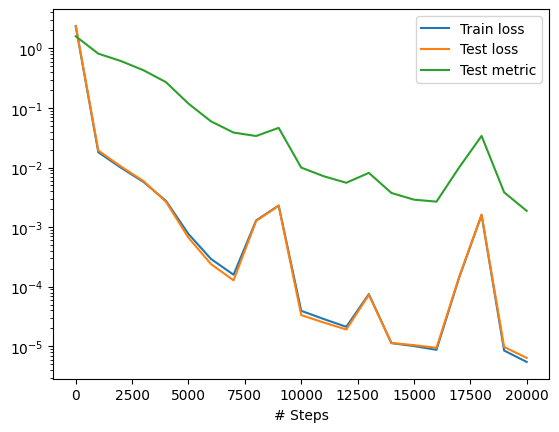

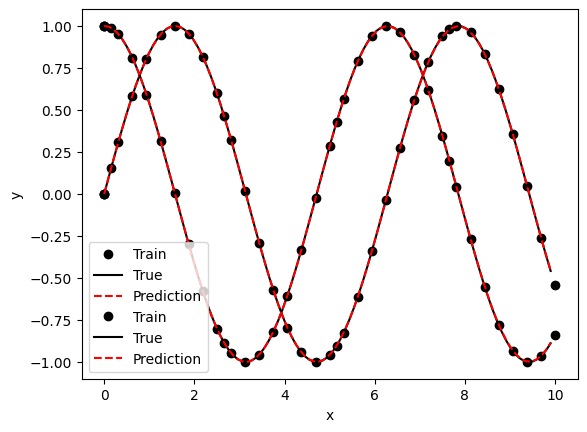

In [2]:
import deepxde as dde
import numpy as np

def ode_system(x, y):
    """ODE system.
    dy1/dx = y2
    dy2/dx = -y1
    """
    
    y1, y2 = y[:, 0:1], y[:, 1:]
    dy1_x = dde.grad.jacobian(y, x, i=0)
    dy2_x = dde.grad.jacobian(y, x, i=1)

    return [dy1_x - y2, dy2_x + y1]


def boundary(_, on_initial):
    return on_initial


def func(x):
    """
    y1 = sin(x)
    y2 = cos(x)
    """

    return np.hstack((np.sin(x), np.cos(x)))


geom = dde.geometry.TimeDomain(0, 10)
ic1 = dde.icbc.IC(geom, lambda x: 0, boundary, component=0)
ic2 = dde.icbc.IC(geom, lambda x: 1, boundary, component=1)
data = dde.data.PDE(geom, ode_system, [ic1, ic2], 35, 2, solution=func, num_test=100)

layer_size = [1] + [50] * 3 + [2]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=20000)

dde.saveplot(losshistory, train_state, issave=False, isplot=True)
